# Unit 2 - Regularization and optimization in deep learning

## 2.1. Introduction to regularization

<!-- * Fuente inicial, pero ya no se edita: *Regularization in Deep Learning*. Peng Lui. Manning. 2023. -->

### 2.1.1 Underfitting and overfitting

#### Generalization

> Generalization is the ability of the model to give correct answers to input data that it has never seen before.

* When we build a machine learning model our main goal is that it *generalizes* well. 
* A model that does not generalize well may suffer from two types of errors, known as **underfitting** and **overfitting**.
* To explain both terms let us imagine that we have the following regression problem where, given certain values on the X-axis (corresponding to our input), we need to estimate the values on the Y-axis (our output).

<img src="images/regularization/generalization_data.png" width=660 height=409/>


#### Underfitting

> Underfitting is the inability of the model to learn the patterns present in the learning data.

* Underfitting lead to poor generalization and inadequate results.
* The causes are varied: it may be because we have not trained enough, the network is too simple and is not able to learn the complexities of the data, we have too little data to generalize from it, etc.

<img src="images/regularization/generalization_underfitting.png" width=626 height=470/>

#### Overfitting

> Overfitting occurs when a model fits the training data so well that it has lost its ability to generalize and its predictions are not correct for new cases.

* The most common cause is that, probably due to an underfitting problem, we have decided to make our model more complex and have made it more complex than necessary: more layers, more neurons per layer, more training *epochs*, etc.

<img src="images/regularization/generalization_overfitting.png" width=629 height=465/>

### 2.1.2. Bias and variance

* Underfitting and overfitting are closely connected to the concept of bias-variance trade-off that occurs in regression, classification and reinforcement learning tasks.

#### Bias

> Bias refers to how close the model prediction is to the target value, on average.

* We want the model to have a low bias as much as possible, thus being close to the actual target value on average.
* A model with a high bias means it fails to capture the underlying pattern in the data and only generates a biased, off-target prediction.
* The trained model, if too simple, will likely end up underfitting the training data.

#### Variance

> Variance measures the variability of the model prediction.

* It shows how wide or narrow the range of model predictions could be.
* We want the model to have a variance as low as possible, thus producing more stable and reliable results.
* A model with high variance often results from too much focus on fitting the training data well, even to the point of exactly matching its predictions to the target labels. 
* When overfitting occurs, the model performs very well on the training data but has a significant error on test data.

<img src="images/regularization/bias_variance_1.png" width=872 height=493/>

#### Bias-variance trade-off

* Generally, as we lower the bias, the variance increases. 
* So the ideal is to find that middle point where we get a trade-off between bias and variance, and both values are low.
* That midpoint will be the midpoint between underfitting and overfitting.

<img src="images/regularization/bias_variance_2.png" width=588 height=398/>

**Why lowering Bias increases Variance**

* **To lower bias**, we must make the model more flexible so it can "fit" the training data more accurately. You might add more parameters, use a higher-degree polynomial, or grow a deeper decision tree.
    - **Result:** The model becomes so flexible that it starts to follow every single data point, including random outliers and noise unique to that specific dataset.
    - **Consequence**: Because the model has "memorized" the quirks of Dataset A, it will perform very differently (high variance) when you give it Dataset B.

**Why lowering Variance increases Bias**

* **To lower variance**, you want the model to be more stable and less "twitchy." You do this by simplifying it (e.g., using regularization or pruning a tree).
    - **Result**: The model becomes "rigid." It ignores the noise, which is good.
    - **Consequence**: It also starts to ignore the actual underlying signal because it’s too simple to capture it (high bias).

* To find this equilibrium point, a common strategy is to visualize the error during training and the error with the validation or test data.
* The moment that the error starts to grow in the test set (but continues to fall in training) is the moment when the network starts to overfit. 

<img src="images/regularization/bias_variance_3.png" width=568 height=434/>

### 2.1.3. Regularization

#### Deep neural networks and overfitting

* Deep neural networks are usually complex models due to their large number of parameters and sophisticated architecture, thus prone to being over-parameterized and overfitting.
* An overly complex model may learn and understand the underlying patterns of the training data very well, but at the same time unconsciously become sensitive to the noises in the training data, resulting in overfitting and not generalizing to the test data.
* Since the actual level of complexity is unknown to us in advance, it is often impossible to jump to the right amount of model complexity during the training stage.
* One of the remedies is to *regularize* the process before or during model training.

#### Regularization

> Regularization is a suite of strategies used to reduce the generalization error of machine learning models, in particular deep learning models.

* Regularization techniques are, therefore, a set of best practices that actively impede the model’s ability to fit perfectly to the training data, with the goal of making the model perform better during validation. 
* This is called “regularizing” the model, because it tends to make the model simpler, more “regular” its curve smoother, more “generic”; thus it is less specific to the training set and better able to generalize. <!--- by more closely approximating the latent manifold of the data. --->
* An adequate regularization could help control the complexity of a neural network, reduce the generalization gap and address the issue of overfitting, while at the same time keeping the training error as low as possible. 

#### Model training process

* A typical model training process is composed of:
    - **Training data**. In supervised learning tasks, the training data consists of input-output pairs.
    - **Model**. A trained model consists of two parts: parameters and architecture. Parameters are the integral components of a model, and the architecture specifies how these components interact with the input data to produce the final prediction output
    - **Cost**. This predicted value is then compared with the ground truth's target output to produce an error metric jointly. Here, the error indicates the current cost on how close or far away it is between the prediction and the actual value.
    - **Optimization**. Following a particular optimization procedure, the training process adjusts the model parameters and sometimes the architecture to reduce the training cost.

<img src="images/regularization/model_training_process.png" width=869 height=490/>

#### Common regularization techniques.

* It typically works by tweaking either data, model architecture, cost function, or optimization procedure to enhance the overall learning algorithm and control the degree of overfitting.

<img src="images/regularization/regularization_techniques.png" width=800/>

### 2.1.4. IMDB example

* The IMDB (Internet Movie Data Base) dataset is a set of reviews on different movies collected from the popular internet site.
* There are 25,000 reviews of which half will be used for training and half for testing. Both halves are composed of 50% positive reviews and 50% negative reviews.
* The data consists of a set of words (the criticism itself), coded as integers (each different word is assigned a number) and a label indicating whether the criticism is positive or negative.
* The data is included in Keras so it is easy to load and use.

In [1]:
import keras
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words = 10000) 

C:\Users\Usuario\anaconda3\envs\DL\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


* The parameter `num_words = 10000` indicates that we will keep the 10,000 most frequent words used in the training set, the rest will be ignored. This allows the data to have a more manageable size.
* Each entry in the training set is a list of integers representing the words available in the critique.

In [2]:
print(train_data[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


* Each case is labeled as a zero or a one indicating a negative or positive criticism respectively.

In [3]:
train_labels[0]

np.int64(1)

* We can take a look at the original review with this little code that converts the numerical indexes back into words (assigning `?` to the word we have not considered because it is not among the 10.000 most common).

In [4]:
# word_index is a dictionary mapping words to integer index
word_index = imdb.get_word_index()

# Reverses it, mapping integer indices to words
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# Decodes de review. Note that the indices are offset by 3 because 0, 1, and 2 are reserved 
# indices por "padding", "start of sequence" and "unknown"
decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in train_data[0]])

In [5]:
decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

#### IMDB: Preparing the data

__multi-hot encoding__ 

* In order to feed the neural network we need to convert the list of integers into a more manageable representation.
* As each review will be composed of words whose indexes range from zero to 9,999, it is easiest to encode our review as an array of 10,000 positions (from 0 to 9,999). In each position there will be a 1 if the word is present in the critique or a zero otherwise.
* This is called a _multi-hot encoding_.
* For example, a criticism that is the sequence of only two words `[3, 5]` will be encoded as an array of 10 000 positions in which only positions `3` and `5` store a one, the rest will be zeros. 
* The 1s and 0s are represented as floating values since neural networks are fed with floating values (for various reasons, including efficiency in making the various calculations).

__Implementing multi-hot encoding__
* In Keras we have a preprocessing layer (`CategoryEncoding`) which encodes integer features.
* See: https://keras.io/api/layers/preprocessing_layers/categorical/category_encoding
* This layer provides options for condensing data into a categorical encoding when the total number of tokens are known in advance. It accepts integer values as inputs, and it outputs a dense or sparse representation of those inputs. 
* But we can also define manually a very easy `multi_hot_encode()` function.

In [6]:
import numpy as np
def vectorize_sequences(sequences, dimension = 10000):
    # Creates an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    
    for i, sequence in enumerate(sequences):
        # Sets specific indices of results[i] to 1s
        results[i, sequence] = 1.
    return results

* Let's see how `vectorized_sequences()` works with a simple example.
* We have the array `a` which we can understand as three lists of words identified by numbers.

In [7]:
a = [[1,2,3],
     [4,5,6],
     [7,8,9]]

* Therefore the end result of calling `vectorize_sequences()` over `a` is:

In [8]:
result = vectorize_sequences(a, 10)
print(result)

[[0. 1. 1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 1.]]


* Let us now apply the `vectorize_sequences` function to our training and test data.

In [9]:
# Vectorized training data
x_train = vectorize_sequences(train_data)

# Vectorized test data
x_test = vectorize_sequences(test_data)

print(x_train[0])

[0. 1. 1. ... 0. 0. 0.]


* The labels must also be converted to `np.array` but in this case the conversion is simple.
* As we can see, the ones and zeros of the labels are also converted to float values.

In [10]:
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

#### IMDB: Building the neural network

__Input layer__
* We will build the network using a sequential Keras model composed of a sequence of densely connected layers (all neurons in one layer connected to all neurons in the next).
* We will have an input layer with 10,000 entries (one for each possible word).

__Hidden layers__
* There are two key architecture decisions to be made about such a stack of Dense layers:
    1. How many layers to use.
    2. How many units to choose for each layer.
* A large network has a bigger representational power but it is more prone to overfitting.
* Unfortunately, there is no magical formula to determine the right number of layers or the right size for each layer. 
* The general workflow for finding an appropriate model size is to start with relatively few layers and parameters, and increase the size of the layers or add new layers until you see diminishing returns with regard to validation loss.
* We decided to include two hidden layers with 16 neurons each with a `relu` activation function.

__Output layer__
* Finally we will have an output layer with a single neuron. The activation of this neuron will be a `sigmoid` function that offers values between zero and one that indicate the probability that the case studied is a zero (negative review) or a one (positive review).  

In [11]:
from keras import models
from keras import layers

# we are using the name parameter to identify better model and layers
model = models.Sequential(name='imdb')

# we create the layers of the model 
model.add(layers.Input(shape=(10000,)))
model.add(layers.Dense(16, name='hidden_1', activation='relu'))
model.add(layers.Dense(16, name='hidden_2',activation='relu'))
model.add(layers.Dense(1, name='output',  activation='sigmoid'))

model.summary()

Model: "imdb"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

* After creating the network structure we have to indicate the learning parameters that we are going to use.
* First of all we have to indicate an error function. 
* As we are working with a model where the final output is a probability the most appropriate function is `binary_crossentropy`.
* We could also have applied `mean_squared_error` but as a general rule `binary_crossentropy` works better with outputs that represent probabilities.
* As an optimizing algorithm we will use `adam` (`rmsprop` is a good alternative also).
* As a validation measure in our test suite we will use `accuracy`.

In [12]:
model.compile(optimizer = 'adam',
             loss = 'binary_crossentropy',
             metrics = ['accuracy'])

## 2.2 Regularization via data


### 2.2.1.	Training, validation and test sets

#### Training and test sets

* In every machine learning model we see that there is a division between the dataset we use to train the model and the dataset we use to check if, finally, the training is adequate.
  
> __Training set__: Used for training the model, i.e. find the optimal values for the parameter of the model (the _weights_ and the _biases_).
>
> __Test set__: Used to obtain a final performance estimate.

* The reason for doing this is to avoid **overfitting** and to get the model to generalize well, so it must be tested with data that have not been used in training.

![dataset-training-test.png](images/regularization/dataset_train_test.png)

* If your model performs very well with training data but its accuracy decreases with test data then it is overfitting.
* In the **MNIST** example we train and test datasets.

#### Validation set

* However, although test data are not used in training, it is possible to use them indirectly.
* The point is that the development of a neural network is an iterative process, different configurations of the number of layers, the neurons in each layer, their activation functions, etc. are tested.
* These data are known as **hyperparameters** to differentiate them from the *parameters* of the network, which are its weights.
* Therefore, if our model does not work (tested with the test set) the hyperparameters are re-adjusted until an acceptable result is achieved.
* In this way the test data is being filtered into the model through hyperparameter fitting, and we may end up overfitting our model to that data and not being able to generalize new data.
* For this reason, test data should never be used for hyperparameter tuning, for this purpose we will reserve part of the training data, known as **validation data**.
  
> __Validation set__: Used for tunning the hyperparameters, i.e. other parameters used in training process (number of epochs, batch size, number of layers, number of neurons, learning rate, etc.)

* This process of separating training data and validation data is known as *hold-out*.

![Validation-set-2.png](images/regularization/dataset_train_val_loop.png)

![dataset-training-validation.png](images/regularization/dataset_train_val.png)

* We are going to divide the IMDB dataset in this way.

#### IMDB with training, validation and test sets

* To monitor the accuracy of the model during training on data that you have not seen before we will divide our training set (`x_train`) into two parts:
    * `x_val` : will be the first 10,000 values of the training set and `y_val` will be their corresponding labels, i.e., the validation set.
    * `partial_x_train` : will be the remaining 15,000 values and `partial_y_train` will be their corresponding labels, i.e., the new training set.

In [13]:
x_val = x_train[:10000] # Copy of x_train from the begining (0) to 9999
partial_x_train = x_train[10000:] # Copy of x_train from 10000 to the end

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

* Now we train the model using `partial_x_train` and `partial_y_train` as training data.
* We repeat the training with these data 20 times (`epoch`).
* The calculations with the loss function and the update of weights is done every 512 cases (`batch_size`).
* Finally the validation data are `x_val` and `y_val` and are passed to the `fit` method using the `validation_data` parameter.


In [14]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs = 20,
                    batch_size = 512,
                    validation_data = (x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7630 - loss: 0.5756 - val_accuracy: 0.8555 - val_loss: 0.4357
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8963 - loss: 0.3337 - val_accuracy: 0.8853 - val_loss: 0.3114
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9260 - loss: 0.2264 - val_accuracy: 0.8888 - val_loss: 0.2801
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9475 - loss: 0.1679 - val_accuracy: 0.8900 - val_loss: 0.2765
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9643 - loss: 0.1246 - val_accuracy: 0.8858 - val_loss: 0.2882
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9762 - loss: 0.0945 - val_accuracy: 0.8821 - val_loss: 0.3075
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9848 - loss: 0.0712 - val_accuracy: 0.8819 - val_loss: 0.3319
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9912 - loss: 0.0527 - val_accuracy: 0.8790 - val_loss

* We can use the `validation_split` parameter of the `fit` method for automatically divide the train test into train and validation
* The value passed is the percentage of training data reserved for validation 

~~~
history = model.fit(x_train,
                    y_train,
                    epochs = 20,
                    batch_size = 512,
                    validation_split = 0.4)
~~~

* The `fit` method returns a `History` object. 
* This object has a `history` property which is a dictionary containing the data of everything that has happened during the training.
* It has four keys: `loss`, `accuracy`, `val_loss`, `val_accuracy`. 
* For each of these keys it has a list of the different values that the parameter has been taking during the training.

In [15]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [16]:
history_dict['loss']

[0.5755859017372131,
 0.33367297053337097,
 0.2264443188905716,
 0.16794170439243317,
 0.12459547817707062,
 0.09446555376052856,
 0.07119624316692352,
 0.052669815719127655,
 0.03914005681872368,
 0.029274335131049156,
 0.021916642785072327,
 0.016559386625885963,
 0.012859263457357883,
 0.010222798213362694,
 0.008092858828604221,
 0.006511836312711239,
 0.005198928993195295,
 0.004232562612742186,
 0.0034644638653844595,
 0.002868552226573229]

* We are going to draw now on a graph how the `loss` and `val_loss` data, and the `accuracy` and the `val_accuracy` data have been varying during the training.
* On the X axis we will have the different *epochs* numbered starting at 1.
* We use the __Matplotlib__ library to draw the graph.

In [17]:
import matplotlib.pyplot as plt

def plot(history):
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(accuracy) + 1)

    plt.plot(epochs, accuracy, "b-o", label="Training accuracy")
    plt.plot(epochs, val_accuracy, "r--o", label="Validation accuracy")
    plt.title("Training and validation accuracy")
    plt.legend()
    plt.figure()

    plt.plot(epochs, loss, "b-o", label="Training loss")
    plt.plot(epochs, val_loss, "r--o", label="Validation loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.show()

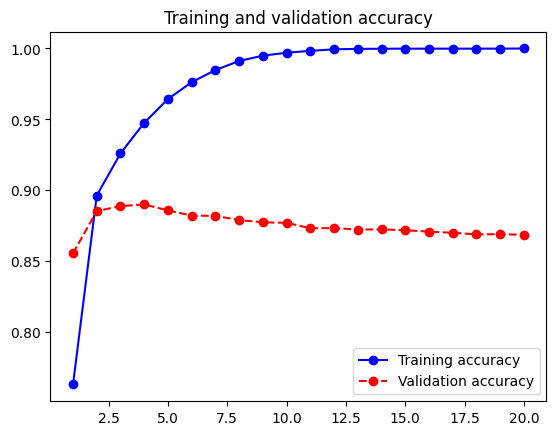

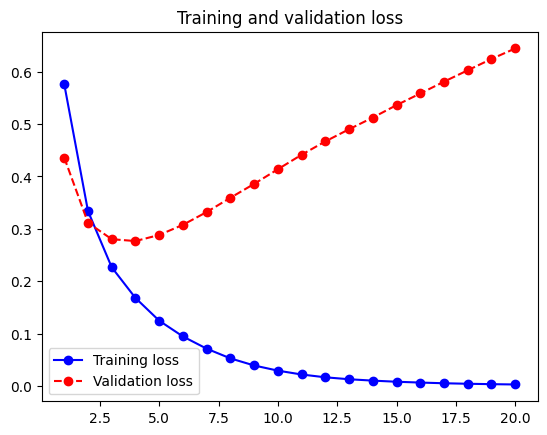

In [18]:
plot(history)

* As we can see during training the error is reduced and the accuracy of the model increases for the cases used in training.
* However, in the data we have set aside for validation we can see how we have a peak in accuracy at the third *epoch* but from there on the accuracy drops.
* What is happening is **overfitting**, the system is adapting too much to the training data, so it is not able to generalize with the validation data.

* We will evaluate the performance of the network using the test data `x_test` and `y_test`.

In [19]:
results = model.evaluate(x_test, y_test)
print(results)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 943us/step - accuracy: 0.8574 - loss: 0.6949
[0.6948535442352295, 0.8573600053787231]


* The first value corresponds to the loss, the second to the accuracy.

### 2.2.2. Cross-validation

* The problem of working with a validation set is that, in the end, the data that we leave for the training of the network (the adjustment of its weights) can be very few, since we have removed the test data and the validation data.
* If the data set is very large, there will be no problem, but if it is not, we may find ourselves with little training data and the network will have trouble learning the correct parameters.  
* In addition, the validation data will be even less, so the validation measures we calculate will be greatly affected by the type of cases chosen as validation.
* To avoid this problem, what is known as __cross-validation__ is used.

####  k-fold cross validation

* Cross validation consists of dividing the training set into K partitions. Then K iterations are performed where K-1 partitions are used for training and one partition for validation. The partition used for validation is different in each iteration.
* The steps would be:
    1. Divide the data into K partitions.
    2. For each partition train the model without a partition to be used for the test.
    3. Once we have iterated over the K partitions we take as validation measure the mean of the validation measures of each partition.
* Finally, the hyperparameters are adjusted according to a validation measure, which is the average of the validation measures of each iteration.

![k_fold_validation.png](images/regularization/k_fold_validation.png)

* Once the hyperparameters have been adjusted, the network is trained again, this time with all the training data and tested with the test data.
* Since we have enough data we are not going to use cross-validation with the IMDB data.

### 2.2.3. Data augmentation

* It consists of creating new synthetic cases from existing ones to increase the number of available training cases.
* We will leave it to see in CNNs, since it is easier to apply with images.
* Generative models, such as GANs, can also be used to create synthetic cases.

## 2.3. Regularization via model

### 2.3.1. Dropout

<!--
Sources of information:
* https://medium.com/@amarbudhiraja/https-medium-com-amarbudhiraja-learning-less-to-learn-better-dropout-in-deep-machine-learning-74334da4bfc5
* https://towardsdatascience.com/simplified-math-behind-dropout-in-deep-learning-6d50f3f47275
* https://machinelearningmastery.com/dropout-regularization-deep-learning-models-keras/
* https://www.kaggle.com/code/ryanholbrook/dropout-and-batch-normalization
-->

#### Definition

* Dropout is a technique where randomly selected neurons are ignored during training. They are "dropped out" randomly. 
* This means that their contribution to the activation of downstream neurons is temporally removed on the forward pass, and any weight updates are not applied to the neuron on the backward pass.
* It was developed by Geoff Hinton and his students at the University of Toronto. 

#### Application

* The *dropout* is applied to a layer and consists of randomly zeroing a series of outputs of the layer during training. 
* So if the output of a layer were the following vector: `[0.2, 0.5, 1.3, 0.8, 1.1]` after applying the *dropout* we would find some randomly distributed zero values: `[0, 0.5, 1.3, 0, 1.1]`. 
* The *dropout* rate is the percentage of values to be set to zero and is usually set between `0.2` and `0.5`. 

#### Dropout rationale

* The motivation for the *dropout* is to eliminate the co-adaptation between neurons that causes them to become highly specialized and lose the ability to generalize.
* The central idea of dropout is to approximate the ensemble learning as if we were to train many different models and average their predictions, since explicitly building multiple models is computationally expensive when the dataset gets large and the model gets complex. 
* The approximation happens by randomly disabling certain nodes in the network (multiplied by zero), making it look like a different model for the current training iteration. 
* Doing so will prevent the model from developing too much reliance on a particular node (as represented by its large weights), since it may just randomly get dropped out of the network. 
* When a seemingly important node is dropped out, the other adjacent nodes will assume the additional shared responsibility for the current training task and learn to be more robust and less prone to co-adaptation, where adjacent nodes exhibit similar behavior and thus hurt generalization performance due to the high correlation.

#### Dropout operation when training

* Let's see how the dropout operation works when training a simple fully-connected neural network with two hidden layers. 
* The probabilistic removal of hidden nodes happens during the training iterations. 
* For example, the second node of the first hidden layer is removed at iteration 1, and the first node of the second hidden layer is removed at iteration 2. 
* Note that muting a node also means silencing (setting to zero) all the connecting weights, as represented by the dashed line. 
* We would end up with the same network architecture as the original version since the dropout operation only happens during training iterations.

![dropout.png](images/regularization/dropout.png)

* In the following image, we can see an animation in which a 50% dropout has been added between the two hidden layers.

![dropout.gif](images/regularization/dropout.gif)


#### Dropout en Keras

* In Keras the *dropout* is applied by adding `Dropout` layers between the normal (`Dense`) layers of the network.
* See: https://keras.io/api/layers/regularization_layers/dropout/
* The following example shows the operation of the IMDB network to which two *dropout* layers have been added after each of the hidden layers.

In [20]:
model = models.Sequential()
model.add(layers.Input(shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(optimizer = 'adam',
             loss = 'binary_crossentropy',
             metrics = ['accuracy'])

history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs = 20,
                    batch_size = 512,
                    validation_data = (x_val, y_val))

history_dict = history.history

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5857 - loss: 0.6647 - val_accuracy: 0.8190 - val_loss: 0.5941
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7238 - loss: 0.5596 - val_accuracy: 0.8557 - val_loss: 0.4647
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8108 - loss: 0.4635 - val_accuracy: 0.8760 - val_loss: 0.3700
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8614 - loss: 0.3889 - val_accuracy: 0.8856 - val_loss: 0.3158
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8901 - loss: 0.3326 - val_accuracy: 0.8876 - val_loss: 0.2908
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9104 - loss: 0.2802 - val_accuracy: 0.8873 - val_loss: 0.2809
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9250 - loss: 0.2427 - val_accuracy: 0.8876 - val_loss: 0.2828
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9368 - loss: 0.2106 - val_accuracy: 0.8879 - val_loss

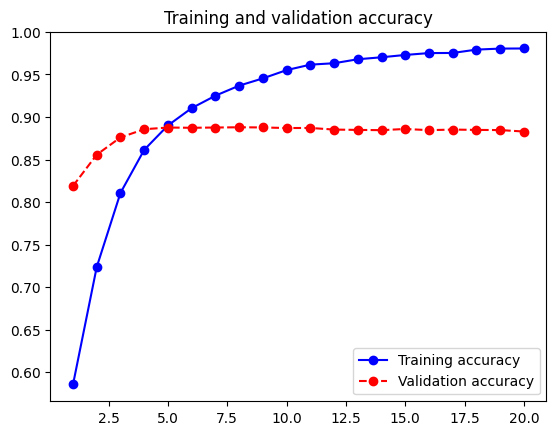

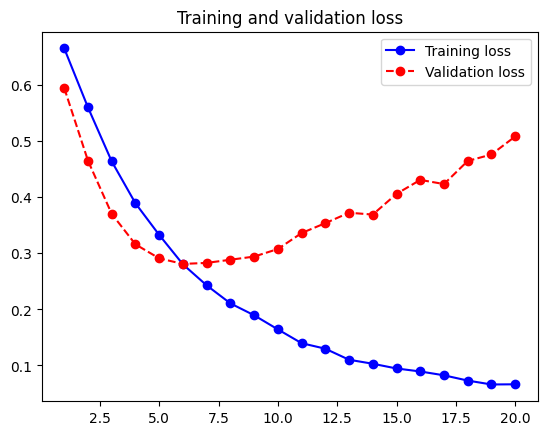

In [22]:
plot(history)

* We can see how the model takes longer to overfit and this overfit is smaller than if the *dropout* did not exist.

In [23]:
results = model.evaluate(x_test, y_test)
print(results)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8743 - loss: 0.5358
[0.5358158349990845, 0.8742799758911133]


### 2.3.2. Batch normalization

<!--    
* Sources of information:
    * https://machinelearningmastery.com/batch-normalization-for-training-of-deep-neural-networks/
    * https://towardsdatascience.com/batch-normalization-in-3-levels-of-understanding-14c2da90a338
    * https://www.kaggle.com/code/ryanholbrook/dropout-and-batch-normalization
-->

#### Definition

* Batch normalization is a method used to make training of artificial neural networks faster and more stable through normalization of the layers' inputs by re-centering and re-scaling.
* Also it is a form of regularization that allows the network to reduce the chances of overfitting.

![batch_normalization.png](images/regularization/batch_normalization.png)

* It is called "batch normalization" because the normalization is done across the mini-batch of data, and independently for each feature:
![batch_normalization_training.webp](images/regularization/batch_normalization_training.webp)


#### Batch normalization functioning

* Batch Normalization is typically applied after a convolutional or fully connected layer and before the activation function (like ReLU).
* For a specific "mini-batch" of data of $M$ samples and for each specific neuron output of the layer ($X$), the process follows these four steps:
    1. **Calculate Mean**: Find the average value of the batch ($\mu$) for a given neuron output.
$$
\mu_i = \frac{\sum X_i}{M}
$$
    2. **Calculate Variance**: Determine how spread out the values are ($\sigma^2$).
$$
\sigma_i^2 = \frac{\sum (X_i-\mu)^2}{M}
$$
    3. **Normalize**: Subtract the mean and divide by the standard deviation. This sets the mean to $0$ and the variance to $1$.
$$
\hat{X_i} = \frac{X_i-\mu_i}{\sqrt{\sigma_i}}
$$
    4. **Scale and Shift**: The model is given two learnable parameters, $\gamma$ (gamma) for scaling and $\beta$ (beta) for shifting, which allow it to undo the normalization if the network decides that a different mean or scale is more efficient for learning.
$$
Y = \gamma \hat{X_i} + \beta
$$
    5. **Track global statistics**.
        * The process captures the global statistical properties of the entire dataset using moving averages for the mean adn the variance
        * **Moving Mean:** $\mu_{mov} = \alpha \cdot \mu_{mov} + (1 - \alpha) \cdot \mu_{\text{batch}}$
        * **Moving Variance:** $\sigma^2_{mov} = \alpha \cdot \sigma^2_{mov} + (1 - \alpha) \cdot \sigma^2_{\text{batch}}$
        * **Where:**
            *  $\alpha$ (alpha) is the **momentum** (typically close to 1, e.g., 0.99).
            *  $\mu_{\text{batch}}$ and $\sigma^2_{\text{batch}}$ are the mean and variance of the current mini-batch.
            * **In a nutshell:** The new moving average is mostly the *old* moving average, plus a tiny fraction of the *current* batch's statistics.

![batch_normalization_moving_averages.png](images/regularization/batch_normalization_moving_averages.png)

#### Batch normalization in Training vs. Inference

* **Training**
    * The process described above is how batch normalization functions during training.
    * It uses the mean and variance of the current mini-batch for normalizing each feature (neuron).
    * It adds two new __learnable parameters__: __gamma__ (for scaling), and __beta__ (for shifting).
    * It adds two new __non-learnable__ parameters:
        * The __Mean Moving Average__ and the __Variance Moving Average__ that are saved as part of the "state" of the Batch Normalizaton layer.
        * They track the "global" statistics of the data (but are not used for normalization).
* **Inference**
    * In inference we cannot calculate a "mean" or "variance" from a single data point.
    * We use the "moving averages" calculated during training to normalize the new data.


#### Batch normalization vs Dropout

* Batch normalization offers __some regularization effect__, reducing generalization error, __reducing the need to use of dropout__ for regularization.
* Also __they conflict in their functioning__:
    - Batch Norm tries to reduce variance by normalizing data to specific statistics (mean and standard deviation).
    - Dropout increases variance by randomly zeroing out neurons, introducing noise.
* __To use them together safely__, we generally follow this specific sequence:
    - Layer (Dense/Conv) $\rightarrow$ Batch Normalization $\rightarrow$ Activation $\rightarrow$ Dropout
* __Why this order?__
    - If we place Dropout before Batch Normalization, the zeros introduced by Dropout will skew the mean and variance calculations of the batch. When we switch to testing (where Dropout is turned off), the Batch Normalization layer sees data with completely different statistics, leading to poor predictions. This is often called the __Variance Shift__.
    - We want Batch Normalization to calculate the statistics of the actual data coming from the layer, not the "holey" data created by Dropout.

![bn_vs_dropout.png](images/regularization/bn_vs_dropout.png)

#### Batch normalization in Keras

* Batch normalization is also a layer that can be used after a layer or between a layer and its activation function:
* See: https://keras.io/api/layers/normalization_layers/batch_normalization/
* Some arguments of the constructor:
    - `momentum`: Momentum for the moving average.  Default is `0.99`.   
    - `center`: If `True`, add offset of `beta` to normalized tensor. If `False`, `beta` is ignored. Default is `True`.
    - `beta_initializer`: Initializer for the beta weight. Default is `"zeros"`.
    - `scale`: If `True`, multiply by `gamma`. If `False`, `gamma` is not used. Default is `True`.
    - `gamma_initializer`: Initializer for the `gamma` weight. Default is `"ones"`.

In [24]:
model = models.Sequential()

# Input layer
model.add(layers.Input(shape=(10000,)))

# Layer 1
model.add(layers.Dense(16, name='hidden_1'))
model.add(layers.BatchNormalization()) # Added BN here
model.add(layers.Activation('relu'))

# Layer 2
model.add(layers.Dense(16, name='hidden_2'))
model.add(layers.BatchNormalization()) # Added BN here
model.add(layers.Activation('relu'))

# Output layer
model.add(layers.Dense(1, name='output', activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,433 (626.69 KB)

 Trainable params: 160,369 (626.44 KB)

 Non-trainable params: 64 (256.00 B)

In [25]:
model.compile(optimizer = 'adam',
             loss = 'binary_crossentropy',
             metrics = ['accuracy'])

history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs = 20,
                    batch_size = 512,
                    validation_data = (x_val, y_val))

history_dict = history.history

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7567 - loss: 0.5108 - val_accuracy: 0.8305 - val_loss: 0.6222
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9241 - loss: 0.2818 - val_accuracy: 0.8632 - val_loss: 0.5377
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9638 - loss: 0.1857 - val_accuracy: 0.8659 - val_loss: 0.4860
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9847 - loss: 0.1222 - val_accuracy: 0.8665 - val_loss: 0.4377
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9947 - loss: 0.0796 - val_accuracy: 0.8647 - val_loss: 0.3991
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9980 - loss: 0.0525 - val_accuracy: 0.8637 - val_loss: 0.3652
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9991 - loss: 0.0358 - val_accuracy: 0.8625 - val_loss: 0.3439
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9997 - loss: 0.0262 - val_accuracy: 0.8566 - val_loss

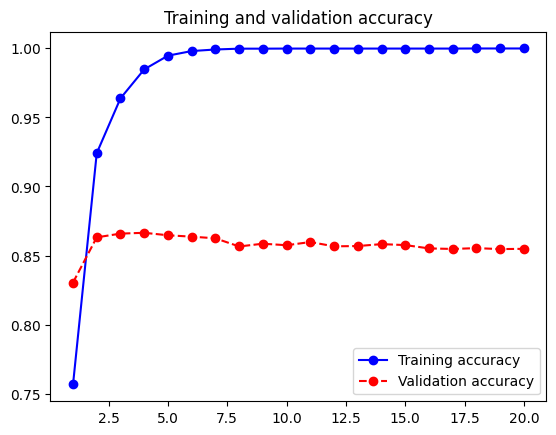

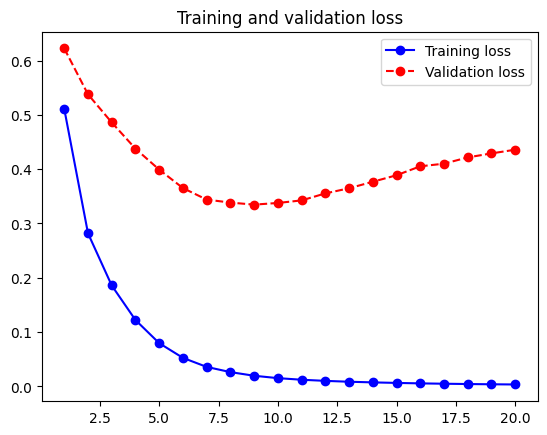

In [26]:
plot(history)

## 2.4. Regularization via objective function

### 2.4.1. Weight Regularization

* A simpler network may give better results than a more complex network (which would over-fit the learning data).
* A simpler network may also mean having "simpler" weights.
* Here by "simple" we mean having less entropy, i.e., restricting the values of the weights to small numbers making their distribution more regular.
* This is known as **regularization of weights**.

#### Core concept

* __Weight regularization adds a penalty term to the Loss Function__.
* The model now has two goals:
    1. Minimize the error (predict accurately).
    2. Minimize the size of the weights (keep them simple).
$$\text{Total Loss} = \text{Prediction Error} + \lambda (\text{Weight Penalty})$$
* Where __$\lambda$ (Lambda) is the regularization strength__.
    * If $\lambda$ is high, the model is forced to have very small weights (high bias).
    * If $\lambda$ is 0, regularization is turned off.
* There are two common ways to calculate this "penalty," and they have very different effects on the model.

#### L1 Regularization (Lasso)

* In L1 the "tax" paid is based on the absolute value of the weights ($|w|$).
$$\text{Penalty} = \lambda \sum |w|$$
* The effect is that it tries to push weights all the way to zero.
* It acts as __Feature Selection__: If a feature is not important, L1 will silence it completely (weight = 0).
* Therefore it creates "sparse" models where only the essential connections remain, and the rest are cut. 
* L1 regularization is generally considered to generate models that are simple and interpretable, but not capable of learning complex patterns.

#### L2 Regularization (Ridge)

* In L2 the "Tax" paid is based on the square of the weights ($w^2$).
$$\text{Penalty} = \lambda \sum w^2$$
* The "tax rate" gets cheaper as the weight gets smaller, therefore, it reduces weights to be very small numbers (e.g., 0.0001), but it almost never hits exactly zero.
* L2 regularization gives rise to more complex models (no zero weights) but is more capable of learning complex patterns.

#### Elastic Net

* Elastic Net is essentially the "middle ground" between L1 and L2 regularization.
* It combines both penalties into a single equation, allowing us to reap the benefits of both techniques while mitigating their individual weaknesses.
* Elastic Net adds both the L1 (absolute value) and L2 (squared) penalties to the loss function.
$$\text{Total Loss} = \text{Error} + \lambda_1 \sum |w| + \lambda_2 \sum w^2$$
* __From L1 (Lasso)__:
    * It inherits the ability to perform feature selection, setting useless weights to exactly zero.
* __From L2 (Ridge)__:
    * It inherits stability. While L1 can behave erratically when features are highly correlated (randomly keeping one and dropping the others), L2 keeps them all but shrinks them.
    * Elastic Net tends to keep "groups" of correlated features together or drop them together.

#### Geometric interpretation

* __L1/Lasso__:
    * The Diamond shape has sharp corners.
    * When the error function (the model trying to learn) hits this shape, it often lands on a corner (where one value is exactly 0).
    * This is why L1 performs Feature Selection.

* __L2/Ridge__:
    * The Circle shape is smooth.
    * The error function hits it along the edge, meaning weights become small but rarely exactly zero.

* __Elastic Net__:
    * it combines L1 and L2.
    * It still has somewhat sharp corners (allowing for feature selection) but bulges out more like a circle (allowing for stability with correlated features).

![geometric_interpretation_L1_L2.png](images/regularization/geometric_interpretation_L1_L2.png)

#### Weight regularization in Keras

* In Keras, weight regularizations are made by passing a regularizer parameter to the model.
* This is done when creating a layer using the `kernel_regularizer` parameter to which we pass an instance of a regularizer, which can be L1 or L2, with its corresponding *lambda* value.
* Let's see the effect of adding such a regularizer to the imdb network we have seen before.

In [27]:
from keras import regularizers

model = models.Sequential(name='imdb')
model.add(layers.Input(shape=(10000,)))
model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.01), activation='relu'))
model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.01), activation='relu'))
model.add(layers.Dense(1, name='output',  activation='sigmoid'))

model.compile(optimizer = 'adam',
             loss = 'binary_crossentropy',
             metrics = ['accuracy'])

history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs = 20,
                    batch_size = 512,
                    validation_data = (x_val, y_val))

history_dict = history.history

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7055 - loss: 0.8588 - val_accuracy: 0.8497 - val_loss: 0.6611
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8763 - loss: 0.5791 - val_accuracy: 0.8738 - val_loss: 0.5424
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8997 - loss: 0.4907 - val_accuracy: 0.8694 - val_loss: 0.5122
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9065 - loss: 0.4524 - val_accuracy: 0.8780 - val_loss: 0.4838
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9157 - loss: 0.4241 - val_accuracy: 0.8831 - val_loss: 0.4691
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9194 - loss: 0.4043 - val_accuracy: 0.8824 - val_loss: 0.4576
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9242 - loss: 0.3883 - val_accuracy: 0.8807 - val_loss: 0.4491
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9235 - loss: 0.3774 - val_accuracy: 0.8813 - val_loss

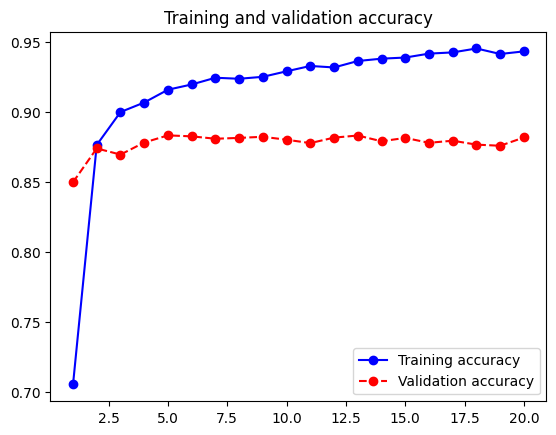

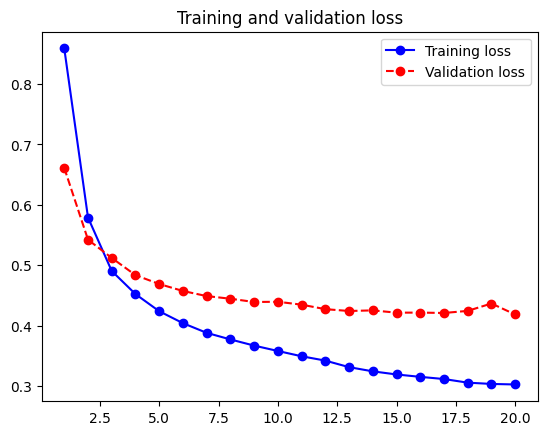

In [28]:
plot(history)

* We can see that although the two networks have the same number of parameters the overfitting is more contained in this second network.
* Using regularizers we can also apply the L1 regularization in Keras or even both at the same time (elastic net).

In [29]:
from keras import regularizers

regularizers.l1(0.001)
regularizers.l1_l2(l1=0.001, l2=0.001)

## 2.5. Optimization


### 2.5.1. Early stopping

* In machine learning, early stopping is a form of regularization used to avoid overfitting.
* Early Stopping monitors the performance of the model for every epoch on a held-out validation set during the training, and terminate the training conditional on the validation performance.
* Basically we stop training as soon as the validation error reaches a minimum, or the validation accuracy doesn't improve over time.

![early_stopping.png](images/regularization/early_stopping.png)
![early_stopping_2.png](images/regularization/early_stopping_2.png)

#### Keras callbacks and early stopping

* Early stopping can be automatically applied in Keras using the `early_stopping` callback.
* A __callback__ is an object that is passed to the model in the call to `fit()` and that is called by the model at various points during training.
* It has access to all the available data about the state of the model and its performance, and it can take action: interrupt training, save a model, load a different weight set, or otherwise alter the state of the model.
* Callbacks are used for:
    - __Model checkpointing__ — Saving the current state of the model at different points during training.
    - __Early stopping__ — Interrupting training when the validation loss is no longer improving (and of course, saving the best model obtained during training).
    - __Dynamically adjusting the value of certain parameters during training__ — Such as the learning rate of the optimizer.
    - __Logging training and validation metrics during training, or visualizing the representations learned by the model as they’re updated__ — The fit() progress bar it is in fact a callback!
* See: https://keras.io/api/callbacks/

#### Early stopping parameters in Keras

* Some important parameters are:
    * `monitor`: The quantity to monitor and decide to stop
    * `mode`: It can be `auto`, `min` or `max`. In `min` mode, training will stop when the quantity monitored has stopped decreasing; in `max` mode it will stop when the quantity monitored has stopped increasing; in `auto` mode, the direction is automatically inferred from the name of the monitored quantity.
    * `patience`: Number of epochs with no improvement after which training will be stopped.
* See: https://keras.io/api/callbacks/early_stopping/

In [30]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', mode="min", patience=3)

In [31]:
# === Build the model ===
model = models.Sequential(name='imdb')
model.add(layers.Input(shape=(10000,)))
model.add(layers.Dense(16, name='hidden_1', activation='relu'))
model.add(layers.Dense(16, name='hidden_2',activation='relu'))
model.add(layers.Dense(1, name='output',  activation='sigmoid'))

model.summary()

# Compile the model
model.compile(optimizer = 'adam',
             loss = 'binary_crossentropy',
             metrics = ['accuracy'])

# Train the model
history = model.fit(x_train,
                    y_train,
                    epochs = 20,
                    batch_size = 512,
                    validation_split = 0.4,
                    callbacks=[early_stopping])

history_dict = history.history

Model: "imdb"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7797 - loss: 0.5390 - val_accuracy: 0.8623 - val_loss: 0.3817
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9027 - loss: 0.2862 - val_accuracy: 0.8847 - val_loss: 0.2899
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9344 - loss: 0.1969 - val_accuracy: 0.8852 - val_loss: 0.2844
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9544 - loss: 0.1467 - val_accuracy: 0.8868 - val_loss: 0.2829
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9669 - loss: 0.1149 - val_accuracy: 0.8840 - val_loss: 0.2959
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9767 - loss: 0.0907 - val_accuracy: 0.8801 - val_loss: 0.3156
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9842 - loss: 0.0714 - val_accuracy: 0.8798 - val_loss: 0.3389


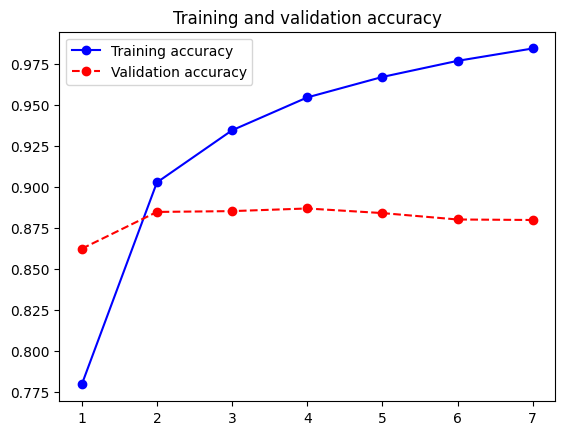

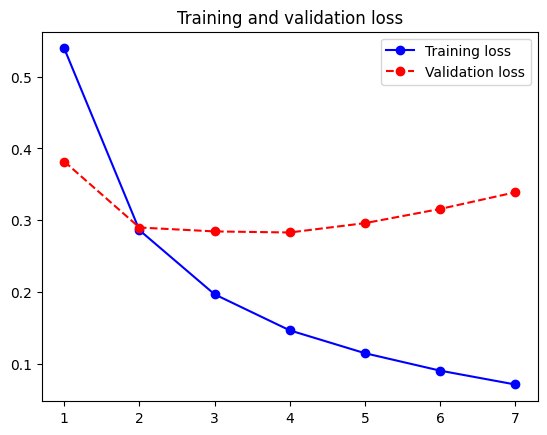

In [32]:
plot(history)

### 2.5.2. Weight initialization 

* In order to be able to train the network, it has to offer, from the very beginning, results for a given input.
* The error function will then determine how to vary the weights so that the network learns to recognize the different input cases.
* But this requires that the weights have a certain initial value. Let's look at several strategies.
<!-- 
* Sources of information:
    * https://medium.com/usf-msds/deep-learning-best-practices-1-weight-initialization-14e5c0295b94
    * https://www.deeplearning.ai/ai-notes/initialization/
    * https://towardsdatascience.com/weight-initialization-techniques-in-neural-networks-26c649eb3b78
-->    

#### Zero weight initialization

* One possibility we can think of is to initialize the weights to zero. 
* But this is not a good idea because it turns our model into a model equivalent to a linear model.
* The derivative with respect to the error function is always the same for each weight, so all weights will have the same values in the next and subsequent iterations.
* In general any initialization of the weights to a constant value will have lousy performance.
* There is no problem with setting the bias (*bias*) to zero as long as the weights are not. Moreover, it is standard practice. Non-zero weights will break the symmetry and the results for each neuron will be different.
* At https://www.deeplearning.ai/ai-notes/initialization/ we have a great simulator that allows us to see this.
* For example if we set the weights to zero we see how the network is unable to learn anything and all the weights in the network have the same values after multiple iterations.

![weight-initialization-zero.png](images/regularization/weight-initialization-zero.png)

#### Random weight initialization

* If we cannot initialize the weights to zero we can initialize them to a random value.
* Following the previous example we see how the network starts to converge quickly and reaches minimum values after three hundred iterations.

![weight-initialization-random.png](images/regularization/weight-initialization-random.png)

* But we must be careful because this can lead to various problems known as **vanishing gradients** or **exploding gradients**.

#### Vanishing gradients

* Vanishing gradients are a problem that occurs when the variations in the weights after each iteration are very small, causing the optimization of the loss function to be very slow or, in the worst case, to stop the learning of the neural network altogether.
* This occurs for example with activation functions such as the hyperbolic tangent or the sigmoid with very large weights that cause the activation function to always present values close to one.
* Functions such as ReLU are more immune to this problem, but may fall into gradient vanishing if the values of the weights are very small. 
* In the image you can see ReLU neurons initialized with very small weights. We can see that the network takes a long time to converge and until iteration 800 it does not reach levels that we previously reached with 300 iterations.

![weight-initialization-vanishing.png](images/regularization/weight-initialization-vanishing.png)

#### Exploding gradients

* Exploding gradients is the opposite case. Very large changes in the values of the weights cause large changes in the error function. The gradients are then very large, causing it to oscillate around the value without falling into it and the model is unable to learn.
* With a ReLU activation function this can happen if the weights have too large values. In the following example you can see how the error function makes very large oscillations and then is unable to find the minimum value.

![weight-initialization-exploding.png](images/regularization/weight-initialization-exploding.png)

#### Different types of weight initialization

* Using the ReLU activation function is a way to avoid vanishing gradients or exploding gradients.
* To avoid the problem, the initialization of the weights must be done according to the following rules:
    - The mean of the activations must be zero.
    - The variance of the activations must be the same across each of the layers.
* This way the gradient signal to be backpropagated will not be multiplied by too large or too small values avoiding the problems of explosion or vanishing.
* __A suitable weight initialization algorithm follows the following steps__:
    1. The biases are initialized to zero.
    2. The weights are randomly chosen from a zero-mean normal distribution.
    3. To choose the standard deviation of the normal distribution we have several possibilities. In them `fan_in` refers to the number of incoming connections (neurons of the previous layer) and `fan_out` refers to the number of outgoing connections (neurons of the next layer).
* __Types of weight initialization__    
    - _He initialization_
        - Proposed by Kaiming He, Researcher at Microsoft: https://arxiv.org/pdf/1502.01852.pdf
        - The standard deviation is calculated as `stddev = sqrt(2 / fan_in)`
    - _Xavier initialization_
        - Named after Xavier Glorot, researcher at the University of Montreal with Yoshua Bengio. (ref. http://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf).
        - The standard deviation is calculated as `stddev = sqrt(1 / fan_in)`
    - _Glorot initialization_
        - Also proposed by Xavier Glorot
        - The standard deviation is calculated as `stddev = sqrt(2 / (fan_in + fan_out))`
    - _Uniform Glorot initialization_
        - In this case the weights are drawn from a uniform distribution (all values are equally likely) in the interval `[-limit, limit]` where `limit` is `sqrt(6 / (fan_in + fan_out))`.

#### Keras initializers

* The different Keras initializers can be consulted at: https://keras.io/initializers/
* The keyword arguments used for passing initializers to layers depends on the layer, but they usually are represented by the following parameters at the Layer constructor: `kernel_initializer` and `bias_initializer`.
* Some available initializers:
    - `RandomNormal`. 
    - `RandomUniform`
    - `Zeros`
    - `Ones`
    - `HeNormal`
    - `GlorotNormal`
    - `GlorotUniform`
    - etc.

In [33]:
# Usage in a Keras layer:
initializer = keras.initializers.HeNormal()
layer = keras.layers.Dense(3, kernel_initializer=initializer)

### 2.5.3. Gradient descent optimization

* Gradient descent is an optimization technique commonly used in training machine learning algorithms.

#### batch size

* We can classify our gradient descent algorithm as follows according to the size of the *batch*:
    * **Batch Gradient Descent**. The size of the batch is equal to the size of the training set.
    * **Stochastic Gradient Descent**: The size of the batch is one.
    * **Mini-Batch Gradient Descent**: The batch size is greater than one but smaller than the training set.
    
* The last case is the most common case, where batch sizes that are powers of two (32, 64, 128, 256, 512, etc.) are usually used.

* The size of the batch influences the following:
    * *Large sizes*: 
        * The calculation is computationally more efficient since the model is updated fewer times.
        * Although more efficient, it also requires more memory to store the results.
        * Fewer updates imply a slower learning speed.
        * The slower update frequency results in a more stable and accurate error gradient. 
    * *Small sizes*
        * The computation is computationally more inefficient since the model is updated more times.
        * Memory requirements are lower.
        * More updates imply faster learning speed.
        * Higher update frequency may incorporate noise in the learning process and cause the model error to vary and may complicate reaching a minimum.

#### Learning rate

* The learning rate is a value that allows us to determine the amount of change we are going to make in the weights in the error backpropagation step.
* Small learning rates cause learning to be slow. 
* Fast learning rates may cause divergent behavior preventing the model from advancing to the minimum of error.

![learning-rate.png](images/regularization/learning-rate.png)

* Choosing the right learning rate is complicated as the way to do it is typically by trial and error.
* Typical rate values start at `0.1` and go down to `0.000001` with `0.001` being a usual value.

![lr-finder.png](images/regularization/lr-finder.png)

**Learning rate decay**
* A common strategy with the learning rate is what is known as decay. 
* Basically, it consists of starting with a relatively high learning rate and lowering it as the training progresses.
* The idea is that at the beginning of learning we want to move fast to reach the right margin of "good" parameters quickly, but once we are close to the minimum of our error function we want to move slower to avoid oscillations.
* Tenemos varias formas de decaimiento pero en ellas básicamente la idea es la misma, ir reduciendo paulatinamiente la tasa de aprendizaje.

#### Momentum

* A parameter that we can add to the gradient descent operation is the *momentum*.
* Momentum in physics is defined as the *amount of motion* calculated as the multiplication of mass times velocity.
* In the case of gradient descent the momentum is a parameter that adds *inertia* to the weight update process, making past updates in a certain direction indicate that this direction will continue in the future.
* In the following image you can see how the momentum works in gradient descent. 
    * The image on the left represents the pure momentum, the changes in the weights have one direction (momentum) and the gradient indicates another, so the final direction is a combination of both.
    * The Nesterov momentum is a modification of the previous one in which the gradient step is calculated from the position where the momentum would take us (not at the current position), so the result is slightly different.

![momentum-nesterov.jpeg](images/regularization/momentum-nesterov.jpeg)

#### Adaptive gradient descent algorithms

* Adaptive gradient descent algorithms are an alternative to stochastic gradient descent (SGD).
* Below is a table summarizing the most common gradient descent optimizers:

<img src="images/regularization/gradient_descent_optimizers.png" width=500 />

* Performance comparison of different gradient descent optimizers:

<img src="images/regularization/gradient_descent_optimizers.gif"  />

<img src="images/regularization/gradient_descent_optimizers_long_valley.gif" width=500 />

<img src="images/regularization/gradient_descent_optimizers_saddle_point.gif" width=500 />

Credit: https://imgur.com/a/Hqolp

#### Keras optimizers

* Documentation: https://keras.io/api/optimizers/
* __Some available optimizers__:
    - SGD: https://keras.io/api/optimizers/sgd/
    - AdaGrad: https://keras.io/api/optimizers/adagrad/
    - RMSProp: https://keras.io/api/optimizers/rmsprop/
    - Adam: https://keras.io/api/optimizers/adam/


In [34]:
import keras
from keras import layers

model = keras.Sequential()
model.add(layers.Input(shape=(10,)))
model.add(layers.Dense(64, ))
model.add(layers.Activation('softmax'))

* We can pass optimizers by name (a string) to the compile method.
* In that case default parameters will be used.

In [35]:
# pass optimizer by name: default parameters will be used
model.compile(loss='categorical_crossentropy', optimizer='adam')

* Or we can instantiate an optimizer object with the corresponding parameters.

In [36]:
opt = keras.optimizers.Adam(learning_rate=0.01)
model.compile(loss='categorical_crossentropy', optimizer=opt)

* __Common parameters__:
    - `learning_rate`: A float, a `keras.optimizers.schedules.LearningRateSchedule` instance, or a callable that takes no arguments and returns the actual value to use. Normally defaults to `0.001` (in SGD is `0.01`).
    - `momentum`: A float. Values higher that `0` accelerate gradient descent in the relevant direction and dampens oscillations. Defaults to `0.0`.

<!--
    - `weight_decay`: Float value. Defaults to `None`. If set, weight decay is applied.
Weight_decay directly influences optimization in optimizers like Adam, while kernel_regularizer adjusts loss function in network layers, penalizing high weights to combat overfitting. Weight_decay affects optimization directly; layer regularization modifies model architecture.
-->

#### Learning rates schedules

* We can use a learning rate schedule to modulate how the learning rate of our optimizer changes over time.
* https://keras.io/api/optimizers/learning_rate_schedules/
* `ExponentialDecay`:
    - A `LearningRateSchedule` that uses an exponential decay schedule.
    - https://keras.io/api/optimizers/learning_rate_schedules/exponential_decay/
* `CosineDecay`: A `LearningRateSchedule` that uses a cosine decay with optional warmup.
    - https://keras.io/api/optimizers/learning_rate_schedules/cosine_decay/

In [37]:
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-2,
    decay_steps=10000,
    decay_rate=0.9)
optimizer = keras.optimizers.SGD(learning_rate=lr_schedule)